# Chapter 2 – Pandas, NumPy, and Matplotlib  
## Part 1: Processing Vaccine Adverse Event Data with pandas
This notebook focuses on **introducing pandas and DataFrame joins** using VAERS as a motivating example.  
To simulate real-world analytical challenges such as missing or incomplete data, we intentionally work with **random subsets of the data** and examine how careless joins can introduce subtle but critical errors.

These concepts are foundational for downstream bioinformatics analyses, including multi-omics integration, clinical data analysis, and large-scale epidemiological studies.



In [78]:
import pandas as pd
import matplotlib.pyplot as plt
vdata = pd.read_csv("C:/Users/razon/Downloads/2021VAERSData/2021VAERSDATA.zip", encoding="iso-8859-1")
vdata.columns
vdata.dtypes
vdata.shape

C:\Users\razon\AppData\Local\Temp\ipykernel_18568\2480601572.py:3: DtypeWarning: Columns (7,12,15,23) have mixed types. Specify dtype option on import or set low_memory=False.
  vdata = pd.read_csv("C:/Users/razon/Downloads/2021VAERSData/2021VAERSDATA.zip", encoding="iso-8859-1")


(768833, 36)

In [79]:
vdata.iloc[0]
vdata = vdata.set_index("VAERS_ID")

In [80]:
vdata.loc[916600]

RECVDATE                                               01/01/2021
STATE                                                          TX
AGE_YRS                                                      33.0
CAGE_YR                                                      33.0
CAGE_MO                                                       NaN
SEX                                                             F
RPT_DATE                                                      NaN
SYMPTOM_TEXT    Right side of epiglottis swelled up and hinder...
DIED                                                          NaN
DATEDIED                                                      NaN
L_THREAT                                                      NaN
ER_VISIT                                                      NaN
HOSPITAL                                                      NaN
HOSPDAYS                                                      NaN
X_STAY                                                        NaN
DISABLE   

In [81]:
vdata.head(3)


,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,DATEDIED,...,HISTORY,PRIOR_VAX,SPLTTYPE,FORM_VERS,TODAYS_DATE,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,ALLERGIES,ORDER
VAERS_ID,,,,,,,,,,,,,,,,,,,,,
908012,01/01/2021,TX,39.0,39.0,NaN,M,NaN,Headache and myalgias started day 2 after vacc...,NaN,NaN,...,NaN,NaN,NaN,2,01/01/2021,NaN,Y,NaN,none,2
909458,01/01/2021,VA,51.0,51.0,NaN,F,NaN,on 12/25 all lymph nodes on the same side as t...,NaN,NaN,...,NaN,NaN,NaN,2,01/01/2021,NaN,NaN,NaN,NaN,2
911996,01/01/2021,TX,49.0,49.0,NaN,F,NaN,Anaphylaxis. Immediately experienced shortness...,NaN,NaN,...,NaN,NaN,NaN,2,01/01/2021,NaN,NaN,Y,"Shellfish, Iodine",2


AGE_YRS
50     12859
65     12660
60     12526
51     12344
59     12210
       ...  
115        6
119        4
106        2
113        1
109        1
Name: count, Length: 111, dtype: int64

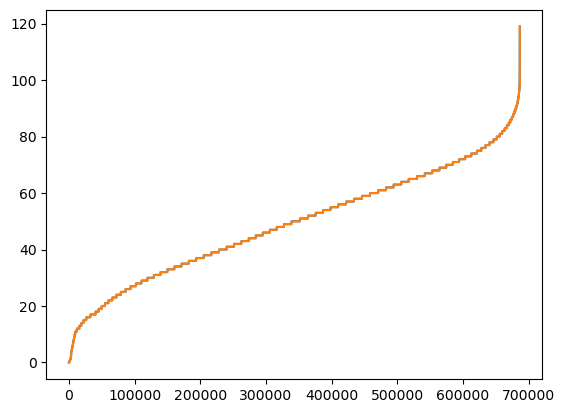

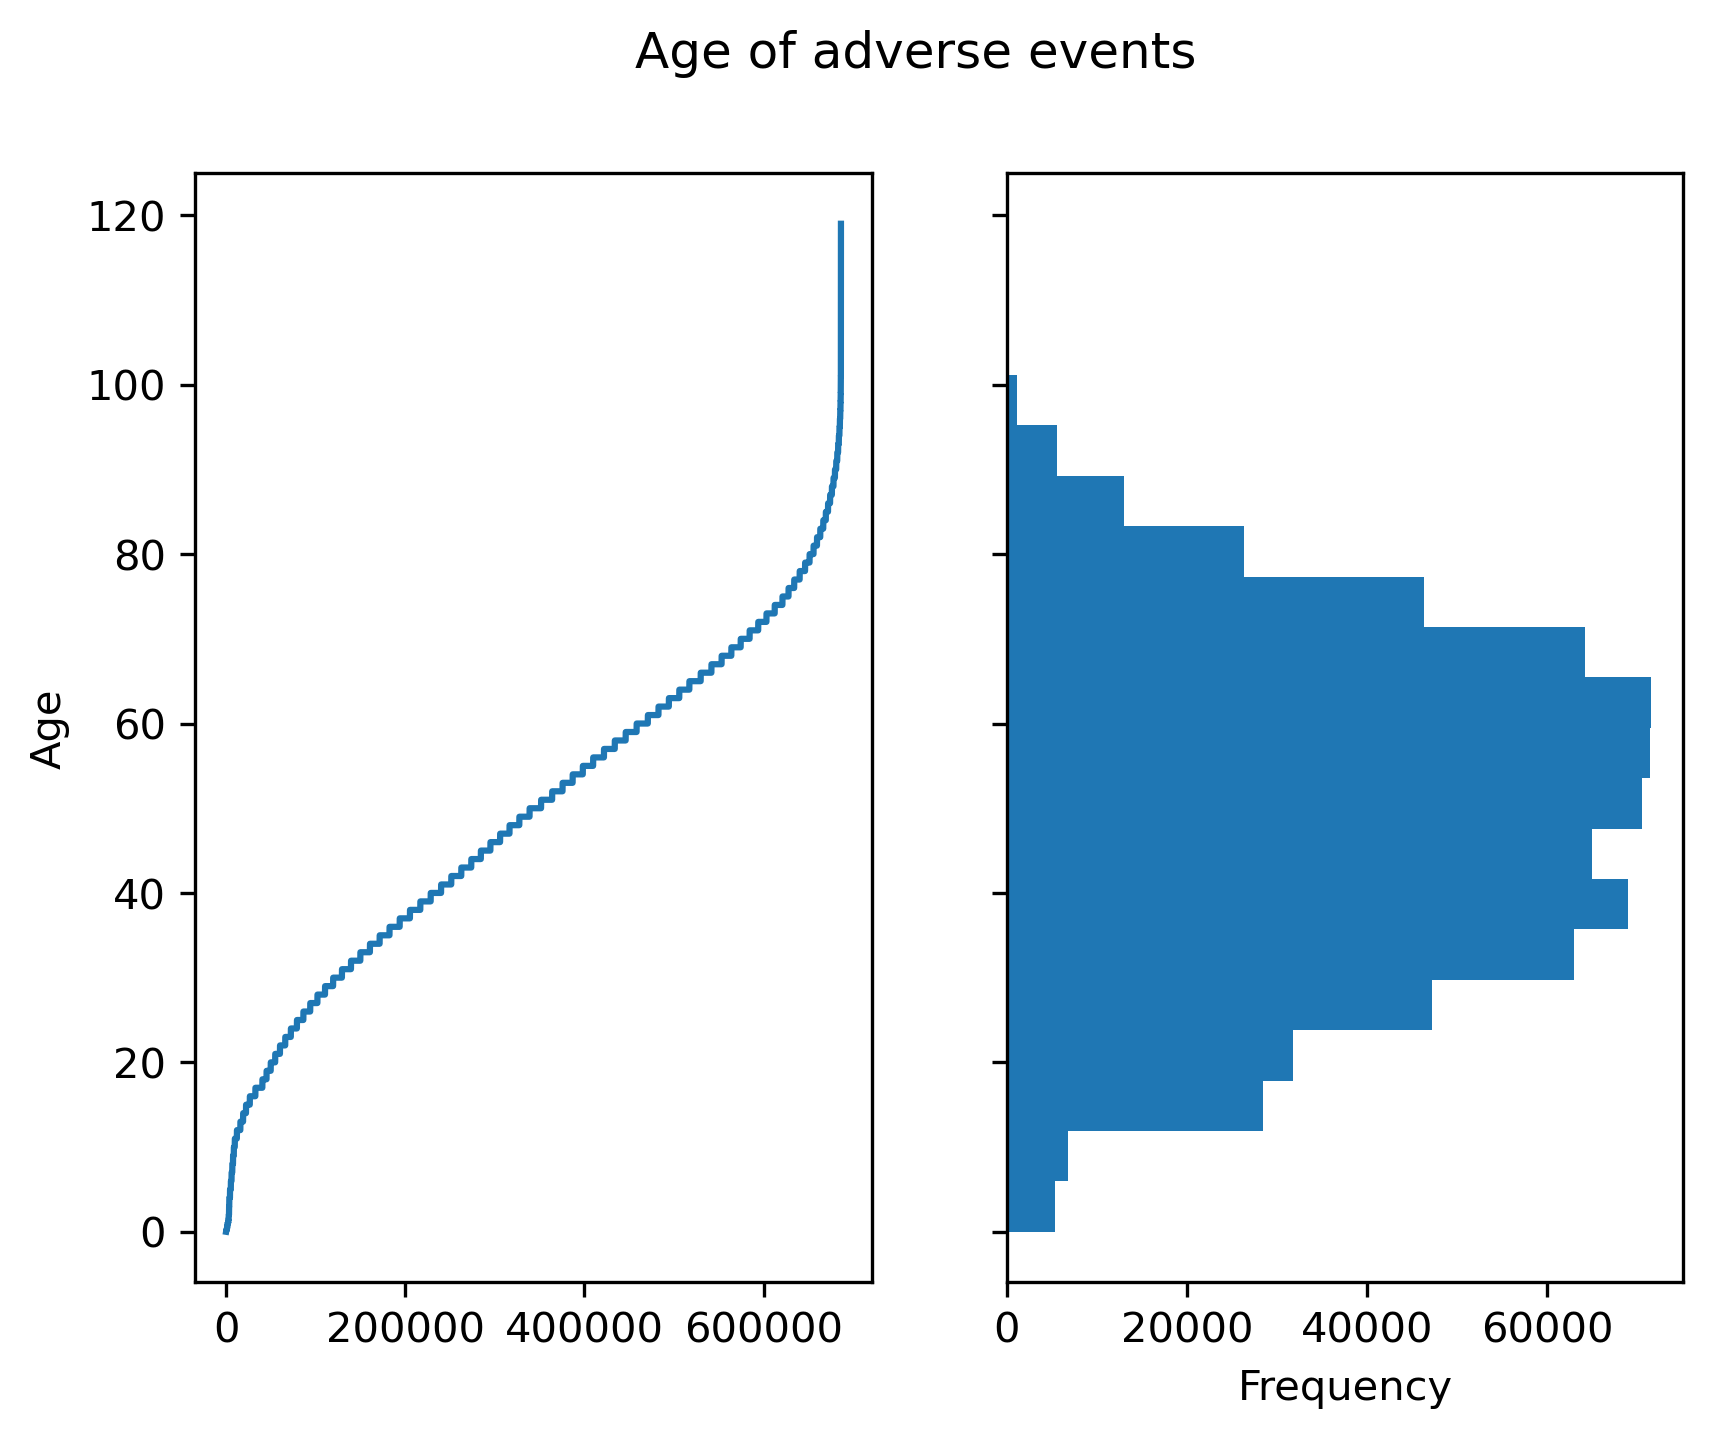

In [82]:
vdata.iloc[:3]

vdata.iloc[:5, 2:4]

vdata["AGE_YRS"].max()

vdata.AGE_YRS.max()



vdata["AGE_YRS"].sort_values().plot(use_index=False)

fig, ax = plt.subplots(1, 2, sharey=True, dpi=300)
fig.suptitle("Age of adverse events")
vdata["AGE_YRS"].sort_values().plot(use_index=False, ax=ax[0], xlabel="Obervation", ylabel="Age")
vdata["AGE_YRS"].plot.hist(bins=20, orientation="horizontal")
fig.savefig("adverse.png")
vdata["AGE_YRS"].dropna().apply(lambda x: int(x)).value_counts()

In [85]:
vdata.DIED.value_counts(dropna=False)
vdata["is_dead"] = (vdata.DIED == "Y") 

In [98]:
dead = vdata[vdata.is_dead]
vax = pd.read_csv("C:/Users/razon/Downloads/2021VAERSData/2021VAERSVAX.zip", encoding="iso-8859-1").set_index("VAERS_ID")
vax.groupby("VAX_TYPE").size().sort_values()
vax19 = vax[vax.VAX_TYPE == "COVID19"]
vax19_dead = dead.join(vax19, lsuffix='_dead', rsuffix='_vax')
vax19_dead.index.value_counts()

VAERS_ID
906910     64
1683324    30
1320653    30
1225926    28
1205423    25
           ..
1261857     1
1261865     1
1262151     1
1262166     1
1998663     1
Name: count, Length: 10701, dtype: int64

In [93]:
vax19_dead

,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,DATEDIED,...,ORDER_dead,is_dead,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME,ORDER_vax
VAERS_ID,,,,,,,,,,,,,,,,,,,,,
916803,01/01/2021,LA,78.0,78.0,NaN,M,NaN,respitory colase,Y,10/18/2020,...,1,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
917117,01/01/2021,AR,82.0,82.0,NaN,M,NaN,"After vaccination, patient tested positive for...",Y,01/01/2021,...,1,True,COVID19,MODERNA,NaN,1,IM,AR,COVID19 (COVID19 (MODERNA)),1.0
917790,01/03/2021,AR,90.0,90.0,NaN,F,NaN,"At the time of vaccination, there was an outbr...",Y,01/03/2021,...,1,True,COVID19,MODERNA,NaN,1,IM,AR,COVID19 (COVID19 (MODERNA)),1.0
917793,01/03/2021,AR,78.0,78.0,NaN,F,NaN,Prior to the administration of the COVID 19 va...,Y,01/02/2021,...,1,True,COVID19,MODERNA,NaN,1,IM,AR,COVID19 (COVID19 (MODERNA)),1.0
892415,01/04/2021,IL,82.0,82.0,NaN,M,NaN,Cardiorespiratory Arrest; Septic shock; Bilate...,Y,10/24/2020,...,2,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996743,12/31/2021,NaN,NaN,NaN,NaN,F,NaN,DEATH; STROKE; VACCINE WEAKENED THE HEART/HEAR...,Y,NaN,...,1,True,COVID19,JANSSEN,Unknown,1,NaN,NaN,COVID19 (COVID19 (JANSSEN)),1.0
1996747,12/31/2021,ME,NaN,NaN,NaN,U,NaN,SUSPECTED COVID-19; SUSPECTED CLINICAL VACCINA...,Y,NaN,...,1,True,COVID19,JANSSEN,NaN,1,OT,NaN,COVID19 (COVID19 (JANSSEN)),1.0
1996751,12/31/2021,NaN,NaN,NaN,NaN,U,NaN,DROPPED DEAD; This spontaneous report received...,Y,NaN,...,1,True,COVID19,JANSSEN,NaN,1,OT,NaN,COVID19 (COVID19 (JANSSEN)),1.0


In [97]:
baddies = vax19_dead.groupby("VAX_LOT").size().sort_values(ascending=False)
for i, (lot, cnt) in enumerate(baddies.items()):
    print(lot, cnt, len(vax19_dead[vax19_dead.VAX_LOT == lot].groupby("STATE")))
    if i == 10:
        break

Unknown 333 37
EN6201 179 34
unknown 160 24
EN5318 151 29
EN6200 147 22
EL9261 138 23
EN6198 128 24
EM9810 118 21
EN6202 116 19
EL9269 114 20
EL3248 109 18


In [103]:

vdata = pd.read_csv("vdata_sample.csv.gz")
vax = pd.read_csv("vax_sample.csv.gz")

vdata_with_vax = pd.merge(
    vdata,
    vax,
    on="VAERS_ID",
    how="inner",
    suffixes=('_vdata', '_vax')
)

print(len(vdata), len(vax), len(vdata_with_vax))

C:\Users\razon\AppData\Local\Temp\ipykernel_18568\2061935910.py:1: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  vdata = pd.read_csv("vdata_sample.csv.gz")


691950 732203 687554


In [104]:
lost_vdata = vdata.loc[~vdata.index.isin(vdata_with_vax.index)]
lost_vdata

lost_vax = vax[~vax["VAERS_ID"].isin(vdata_with_vax["VAERS_ID"])]
lost_vax

,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME,ORDER
18,1092866,COVID19,MODERNA,012L20A,1,IM,LA,COVID19 (COVID19 (MODERNA)),1
19,1785429,COVID19,MODERNA,001C21A,1,IM,LA,COVID19 (COVID19 (MODERNA)),1
48,1311716,COVID19,PFIZER\BIONTECH,NaN,2,NaN,NaN,COVID19 (COVID19 (PFIZER-BIONTECH)),1
72,931747,COVID19,MODERNA,037K20A,1,SYR,LA,COVID19 (COVID19 (MODERNA)),1
80,991846,COVID19,MODERNA,012L20A,1,IM,LA,COVID19 (COVID19 (MODERNA)),1
...,...,...,...,...,...,...,...,...,...
732170,956080,COVID19,MODERNA,025J202A,UNK,NaN,NaN,COVID19 (COVID19 (MODERNA)),1
732171,1423795,PNC13,PFIZER\WYETH,DW3411,4,IM,LL,PNEUMO (PREVNAR13),1
732177,1885721,COVID19,MODERNA,939903,3,SYR,LA,COVID19 (COVID19 (MODERNA)),1
732196,1392459,COVID19,MODERNA,039A21A,2,IM,LA,COVID19 (COVID19 (MODERNA)),1


In [107]:
overlaps = vdata.columns.intersection(vax.columns)
print(overlaps)

Index(['VAERS_ID', 'ORDER'], dtype='object')
